In [2]:
with open("./EvaluationGradientBasedImportance.txt","r") as file:
    text = file.read()
    
len(text)

612644

In [3]:
import re
import matplotlib.pyplot as plt

entries = re.split(r'-{20,}', text)
len(entries)

245

In [4]:
# Extract prediction information
data = []
for entry in entries:
    original_pred_match = re.search(r"Model original prediction:\s+(\d+)\s+([\d.]+)", entry)
    without_topk_match = re.search(r"Model w/out top-k:\s+(\d+)\s+([\d.]+)", entry)
    
    if original_pred_match and without_topk_match:
        original_label, original_conf = original_pred_match.groups()
        no_topk_label, no_topk_conf = without_topk_match.groups()
        data.append({
            "Original Prediction": int(original_label),
            "Original Confidence": float(original_conf),
            "Without Top-K Prediction": int(no_topk_label),
            "Without Top-K Confidence": float(no_topk_conf)
        })

In [7]:
import pandas as pd
from utils.read_jsonl import read_jsonl

In [ ]:
df = pd.DataFrame(data)

In [6]:
df["Change in Confidence"] = df["Original Confidence"] - df["Without Top-K Confidence"]

In [7]:
df_0 = df[df["Original Prediction"] == 0]
df_1 = df[df["Original Prediction"] == 1]
len(df_0), len(df_1)

(131, 112)

In [8]:
df_0_same_label = df_0[df_0["Without Top-K Prediction"] == df_0["Original Prediction"]]
len(df_0_same_label), df_0_same_label["Change in Confidence"].min(), df_0_same_label["Change in Confidence"].max(), df_0_same_label["Change in Confidence"].mean()

(131, 0.012448370456695557, 0.4857751131057739, 0.08973825250873128)

In [9]:
df_1_same_label = df_1[df_1["Without Top-K Prediction"] == df_1["Original Prediction"]]
len(df_1_same_label), df_1_same_label["Change in Confidence"].mean()

(46, 0.23888419115025064)

In [10]:
df_1_changed_label = df_1[df_1["Without Top-K Prediction"] != df_1["Original Prediction"]].copy()
df_1_changed_label["Change in Confidence"] = df_1_changed_label["Original Confidence"] - 1.0 + df_1_changed_label["Without Top-K Confidence"]
len(df_1_changed_label), df_1_changed_label["Change in Confidence"].mean()

(66, 0.7740751766797268)

In [11]:
df_1_merged = pd.concat([df_1_same_label,df_1_changed_label])

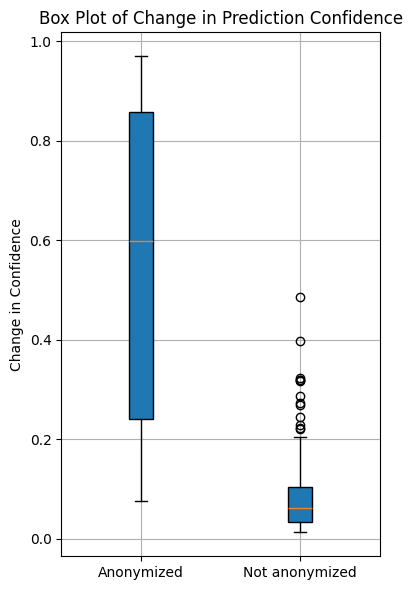

In [12]:
data = [
    df_1_merged["Change in Confidence"],
    df_0_same_label["Change in Confidence"],

]

# Create the box plots side by side
plt.figure(figsize=(4, 6))
plt.boxplot(data,
            vert=True,
            patch_artist=True,
            positions=[1, 2])  # side-by-side positions

# Add title and labels
plt.title("Box Plot of Change in Prediction Confidence")
plt.ylabel("Change in Confidence")
plt.xticks([1, 2], [ "Anonymized", "Not anonymized",])  # label x-axis
plt.grid(True)
plt.tight_layout()
plt.show()